# Raw OPM-MEG to Surface-Based Timeseries

This notebook takes a sample OPM-MEG, LIDAR, and MRI dataset through to:

- manual alignment with YORC, producing an aligned FIF plus a matching `_trans.fif`
- MNE-native source imaging on the aligned data
- ROI-parcellated rendering of the response near 90 ms
- extraction of a V1/occipital-pole proxy timecourse

The notebook now drives sample-data setup, ROI definition, source projection, and surface rendering through the toolbox API. Internally, the toolbox delegates the source-estimation math to MNE-Python.


## Prerequisites

Run the notebook from the `opm-source-toolbox` repository with an environment that includes the optional surface and alignment dependencies. For example:

```bash
uv sync --extra dev --extra surface --extra alignment-qc
```

The notebook expects the YORC GUI extract to be available at `/raid/toolbox/git/yorc/yorc-gui-extract` unless you override `YORC_GUI_REPO` below.

In [1]:
from __future__ import annotations

import os
import json
import sys
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np

%matplotlib inline

# Make local src/ importable when the package is not installed in the active kernel.
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'opm_source_toolbox').exists():
        src_str = str(src_dir)
        if src_str not in sys.path:
            sys.path.insert(0, src_str)
        break

from opm_source_toolbox import (
    SourceProjectionConfig,
    build_bem,
    detect_primary_events,
    export_manifest_to_rois,
    prepare_sample_dataset,
)

plt.rcParams['figure.figsize'] = (10, 4)
mne.set_log_level('WARNING')
os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')

'true'

In [2]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'opm_source_toolbox').exists():
            return candidate
    raise RuntimeError('Could not locate the opm-source-toolbox repository root.')


repo_root = find_repo_root(Path.cwd())
yorc_repo = Path(os.environ.get('YORC_GUI_REPO', '/raid/toolbox/git/yorc/yorc-gui-extract')).resolve()
work_dir = repo_root / 'docs' / 'notebook_data' / 'opm_surface_tutorial'

print(f'repo_root   : {repo_root}')
print(f'yorc_repo   : {yorc_repo}')
print(f'working data: {work_dir}')

repo_root   : /probox/raid/toolbox/git/opm-source-toolbox
yorc_repo   : /probox/raid/toolbox/git/yorc/yorc-gui-extract
working data: /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial


In [3]:
dataset = prepare_sample_dataset(work_dir=work_dir)
subject_dir = dataset.subject_dir
subjects_dir = dataset.subjects_dir
subject_name = dataset.subject_name
raw_fif = dataset.raw_fif
inside_mesh = dataset.inside_mesh
outside_mesh = dataset.outside_mesh
mri_scalp = dataset.mri_scalp
aligned_fif = dataset.aligned_fif
aligned_trans = dataset.aligned_trans
bem_solution = dataset.bem_solution

print(f'subject_name : {subject_name}')
print(f'subject_dir  : {subject_dir}')
print(f'subjects_dir : {subjects_dir}')
print(f'bem_solution : {bem_solution}')
print(f'aligned_fif  : {aligned_fif}')
print(f'aligned_trans: {aligned_trans}')

subject_name : FS
subject_dir  : /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/subjects_download/FS
subjects_dir : /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/subjects_download
bem_solution : /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/subjects_download/FS/bem/FS-bem-sol.fif
aligned_fif  : /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/sampleData/VEP_DS-aligned_raw.fif
aligned_trans: /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/sampleData/VEP_DS-aligned_raw_trans.fif


## Alignment with YORC

The YORC GUI step is manual. The notebook prepares a copy of the raw FIF so that the original sample file stays untouched. Use the copy as the GUI input. When you click **Apply to FIF**, YORC will:

- update that aligned FIF with the `dev->head` transform
- write a separate `_trans.fif` beside it

Follow the `Legacy Mode` workflow from the YORC user guide:

1. Auto-load the files.
2. Click **Auto Helmet Fids** or place the 7 inside fiducials manually.
3. Pick `RPA`, `LPA`, `Nasion` on the outside scan.
4. Pick `RPA`, `LPA`, `Nasion` on the MRI scalp.
5. Click **Compute Transforms**.
6. Click **Preview Sensors** and inspect the fit.
7. Click **Apply to FIF**.

In [4]:
yorc_python = yorc_repo / '.venv' / 'bin' / 'python'
yorc_cmd = [
    str(yorc_python),
    '-m',
    'scripts.tripanel_registration_gui',
    '--inside-mesh', str(inside_mesh),
    '--outside-mesh', str(outside_mesh),
    '--mri-scalp', str(mri_scalp),
    '--megdata', str(aligned_fif),
    '--auto-load',
]

print('Run this command in a terminal or set RUN_YORC_GUI = True below:')
print(' '.join(yorc_cmd))

RUN_YORC_GUI = False
if RUN_YORC_GUI:
    subprocess.run(yorc_cmd, cwd=yorc_repo, check=True)

Run this command in a terminal or set RUN_YORC_GUI = True below:
/probox/raid/toolbox/git/yorc/yorc-gui-extract/.venv/bin/python -m scripts.tripanel_registration_gui --inside-mesh /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/sampleData/Rxxxx_InHelmet.ply --outside-mesh /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/sampleData/Rxxxx_01_Outside.ply --mri-scalp /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/sampleData/FS/surf/mriscalp.stl --megdata /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/sampleData/VEP_DS-aligned_raw.fif --auto-load


In [5]:
if not aligned_fif.exists():
    raise FileNotFoundError(f'Missing aligned FIF: {aligned_fif}')
if not aligned_trans.exists():
    raise FileNotFoundError(
        f'Missing transform file: {aligned_trans}. Run the YORC alignment step and click Apply to FIF.'
    )

print('Aligned inputs are present and ready for source imaging.')

Aligned inputs are present and ready for source imaging.


In [6]:
raw = mne.io.read_raw_fif(aligned_fif, preload=True, verbose=False)
event_result = detect_primary_events(raw)
events = event_result.events
event_id = event_result.event_id
event_source = event_result.source

print(f'Loaded raw data with {len(raw.ch_names)} channels')
print(f'Using events from: {event_source}')
print(f'Event selection  : {event_id}')
print(f'Number of events : {len(events)}')

Loaded raw data with 128 channels
Using events from: di48
Event selection  : {'visual': np.int64(6291711)}
Number of events : 282


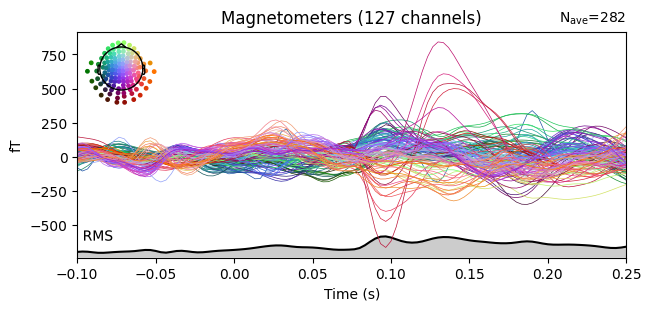

In [7]:
raw_for_epochs = raw.copy()
meg_picks = mne.pick_types(raw_for_epochs.info, meg=True, ref_meg=False, exclude='bads')
raw_for_epochs.filter(l_freq=1.0, h_freq=40.0, picks=meg_picks, verbose=False)

epochs = mne.Epochs(
    raw_for_epochs,
    events,
    event_id=event_id,
    tmin=-0.1,
    tmax=0.25,
    baseline=(None, 0.0),
    preload=True,
    reject_by_annotation=True,
    verbose=False,
)
evoked = epochs.average()
noise_cov = mne.compute_covariance(epochs, tmax=0.0, method='shrunk', verbose=False)

evoked.plot(spatial_colors=True, gfp=True, show=False)
plt.show()

In [8]:
derived_dir = work_dir / 'derived'
exports_dir = derived_dir / 'toolbox_exports'
derived_dir.mkdir(parents=True, exist_ok=True)
exports_dir.mkdir(parents=True, exist_ok=True)

evoked_fif = derived_dir / 'vep-evoked-ave.fif'
evoked.save(str(evoked_fif), overwrite=True)

manifest_path = derived_dir / 'toolbox_manifest.json'
manifest_payload = {
    'subjects': [
        {
            'subject': 'sample',
            'subject_dir': str(subjects_dir),
            'fs_subject': subject_name,
            'items': [
                {
                    'name': 'vep_evoked',
                    'fif_path': str(evoked_fif),
                    'fif_kind': 'evoked',
                    'evoked_index': 0,
                    'source_file': str(aligned_fif),
                    'trans_path': str(aligned_trans),
                }
            ],
        }
    ]
}
manifest_path.write_text(json.dumps(manifest_payload, indent=2), encoding='utf-8')

# The toolbox Schaefer path morphs labels from fsaverage, so make sure fsaverage exists.
fsaverage_dir = Path(mne.datasets.fetch_fsaverage(verbose=True))
atlas_subjects_dir = fsaverage_dir.parent

# Build a BEM solution only when the sample anatomy does not already provide one.
subject_bem_dir = subject_dir / 'bem'
subject_bem_dir.mkdir(parents=True, exist_ok=True)
bem_solution_candidates = sorted(subject_bem_dir.glob('*-bem-sol.fif'))
if bem_solution_candidates:
    bem_solution_path = bem_solution_candidates[0]
else:
    print('No BEM solution found, building one-layer BEM (this can take a while)...')
    bem_solution_path = build_bem(subject_dir=subject_dir, subject_name=subject_name, subjects_dir=subjects_dir)
print(f'Using BEM solution: {bem_solution_path}')

toolbox_config = SourceProjectionConfig(
    atlas_parc='Schaefer2018_200Parcels_7Networks_order',
    atlas_subject='fsaverage',
    atlas_subjects_dir=str(atlas_subjects_dir),
    source_spacing='oct6',
    inverse_kind='mne',
    mne_method='MNE',
    mne_pick_ori='normal',
    label_mode='pca_flip',
    estimate_covariance=False,
    snr=3.0,
    conductor_kind='bem',
)

subject_out_paths = export_manifest_to_rois(
    manifest_path=str(manifest_path),
    out_root=str(exports_dir),
    config=toolbox_config,
    output_format='npz',
)
subject_export_dir = Path(subject_out_paths[0])
metadata = json.loads((subject_export_dir / 'metadata.json').read_text(encoding='utf-8'))
item_meta = metadata['items'][0]

roi_npz = subject_export_dir / item_meta['output_file']
with np.load(roi_npz, allow_pickle=False) as payload:
    roi_names = payload['names'].astype(str).tolist()
    roi_data = np.asarray(payload['data'], dtype=float)

sfreq_hz = float(item_meta['sfreq_hz'])
time_start_s = float(item_meta['time_start_s'])
roi_times_s = time_start_s + (np.arange(roi_data.shape[1]) / sfreq_hz)

# Default plotting mode is cortical power; switch to 'signed' when needed.
metric_mode = 'power'  # options: 'power', 'signed'
if metric_mode == 'power':
    roi_metric_data = roi_data ** 2
    metric_label = 'Cortical power (a.u.^2)'
elif metric_mode == 'signed':
    roi_metric_data = roi_data
    metric_label = 'Source amplitude (a.u.)'
else:
    raise ValueError(f"Unsupported metric_mode: {metric_mode}")

target_time_ms = 100.0
target_time_s = target_time_ms / 1e3
t90_index = int(np.argmin(np.abs(roi_times_s - target_time_s)))
t90_s = float(roi_times_s[t90_index])
roi_values_t90 = roi_metric_data[:, t90_index]

print(f"Toolbox export dir: {subject_export_dir}")
print(f"Atlas            : {metadata['atlas_parc']}")
print(f"ROI matrix shape : {roi_data.shape}")
print(f"Metric           : {metric_mode}")
print(f"Nearest sample to {target_time_ms:.0f} ms: {t90_s * 1e3:.1f} ms")
if metric_mode == 'power':
    print(f"Max ROI power @ {target_time_ms:.0f} ms: {np.max(roi_values_t90):.3e}")
else:
    print(f"Max |ROI value| @ {target_time_ms:.0f} ms: {np.max(np.abs(roi_values_t90)):.3e}")

# Quick sanity check: show strongest parcels at the target time.
top_idx = np.argsort(np.abs(roi_values_t90))[::-1][:8]
print(f"Top |ROI| parcels at target time ({metric_mode}):")
for idx in top_idx:
    print(f"  - {roi_names[idx]}: {roi_values_t90[idx]:.3e}")

0 files missing from root.txt in /probox/raid/data/P1507_tetris/freesurfer_subjects
0 files missing from bem.txt in /probox/raid/data/P1507_tetris/freesurfer_subjects/fsaverage


/raid/toolbox/git/opm-source-toolbox/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using BEM solution: /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/subjects_download/FS/bem/FS-bem-sol.fif
Toolbox export dir: /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_exports/sample
Atlas            : Schaefer2018_200Parcels_7Networks_order
ROI matrix shape : (200, 106)
Metric           : power
Nearest sample to 100 ms: 100.0 ms
Max ROI power @ 100 ms: 1.373e-20
Top |ROI| parcels at target time (power):
  - 7Networks_RH_Vis_6-rh: 1.373e-20
  - 7Networks_RH_Vis_8-rh: 1.086e-20
  - 7Networks_RH_Vis_4-rh: 7.099e-21
  - 7Networks_RH_Vis_9-rh: 5.480e-21
  - 7Networks_RH_Vis_3-rh: 3.824e-21
  - 7Networks_LH_Vis_7-lh: 3.166e-21
  - 7Networks_LH_Vis_4-lh: 2.438e-21
  - 7Networks_LH_Vis_10-lh: 2.042e-21


In [9]:
import importlib
import opm_source_toolbox.roi_surface_render as roi_surface_render

# Ensure this kernel uses the latest renderer code (including medial views).
roi_surface_render = importlib.reload(roi_surface_render)

if metric_mode == 'power':
    vmax = float(np.max(roi_values_t90))
    if vmax <= 0.0:
        raise RuntimeError('All ROI power values are zero at target time; nothing to render.')
    roi_values_display = roi_values_t90 / vmax
    render_cfg = roi_surface_render.SurfaceRenderConfig(
        color_mode='positive',
        vmin=0.0,
        vmax=1.0,
        threshold=0.20,
    )
else:
    absmax = float(np.max(np.abs(roi_values_t90)))
    if absmax <= 0.0:
        raise RuntimeError('All ROI values are zero at target time; nothing to render.')
    roi_values_display = roi_values_t90 / absmax
    render_cfg = roi_surface_render.SurfaceRenderConfig(
        color_mode='symmetric',
        vmin=-1.0,
        vmax=1.0,
        threshold=0.20,
    )

render_result = roi_surface_render.render_roi_vector_to_surface(
    roi_names=roi_names,
    values=roi_values_display,
    out_dir=str(derived_dir),
    stem='toolbox_t100_response',
    title=f"Schaefer ROI response at {t90_s * 1e3:.1f} ms ({metric_mode}, target {target_time_ms:.0f} ms)",
    config=render_cfg,
)

print(f"Montage: {render_result['montage_path']}")
print('Tiles:')
for tile in render_result['tile_paths']:
    print(f'  - {tile}')

Montage: /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_montage.png
Tiles:
  - /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_left_lateral.png
  - /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_right_lateral.png
  - /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_left_medial.png
  - /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_right_medial.png
  - /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_left_dorsal.png
  - /probox/raid/toolbox/git/opm-source-toolbox/docs/notebook_data/opm_surface_tutorial/derived/toolbox_t100_response_right_dorsal.png


In [10]:
montage = plt.imread(render_result['montage_path'])
plt.figure(figsize=(12, 8))
plt.imshow(montage)
plt.axis('off')
plt.title(f"Toolbox-rendered ROI montage at {t90_s * 1e3:.1f} ms")
plt.show()

/tmp/ipykernel_526478/4291417925.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## V1 / Occipital ROI Timecourses

The toolbox export gives ROI names and timecourses directly. This final plot overlays only the V1/occipital-like parcels on the same axes. ROIs are selected by matching atlas names that contain one of: `vis`, `pericalcarine`, `calcarine`, `occipital`, or `v1`. Left-hemisphere parcels are drawn in red hues, right-hemisphere parcels in green hues. The vertical dashed line marks the 100 ms target latency.

By default the notebook plots cortical power (`metric_mode='power'`) rather than signed amplitude. Set `metric_mode='signed'` in the ROI export cell to switch back.

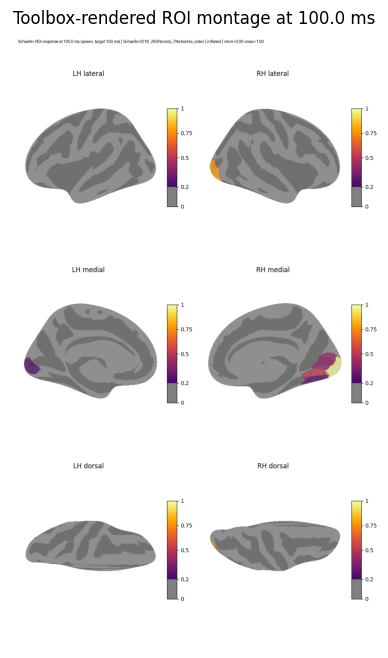

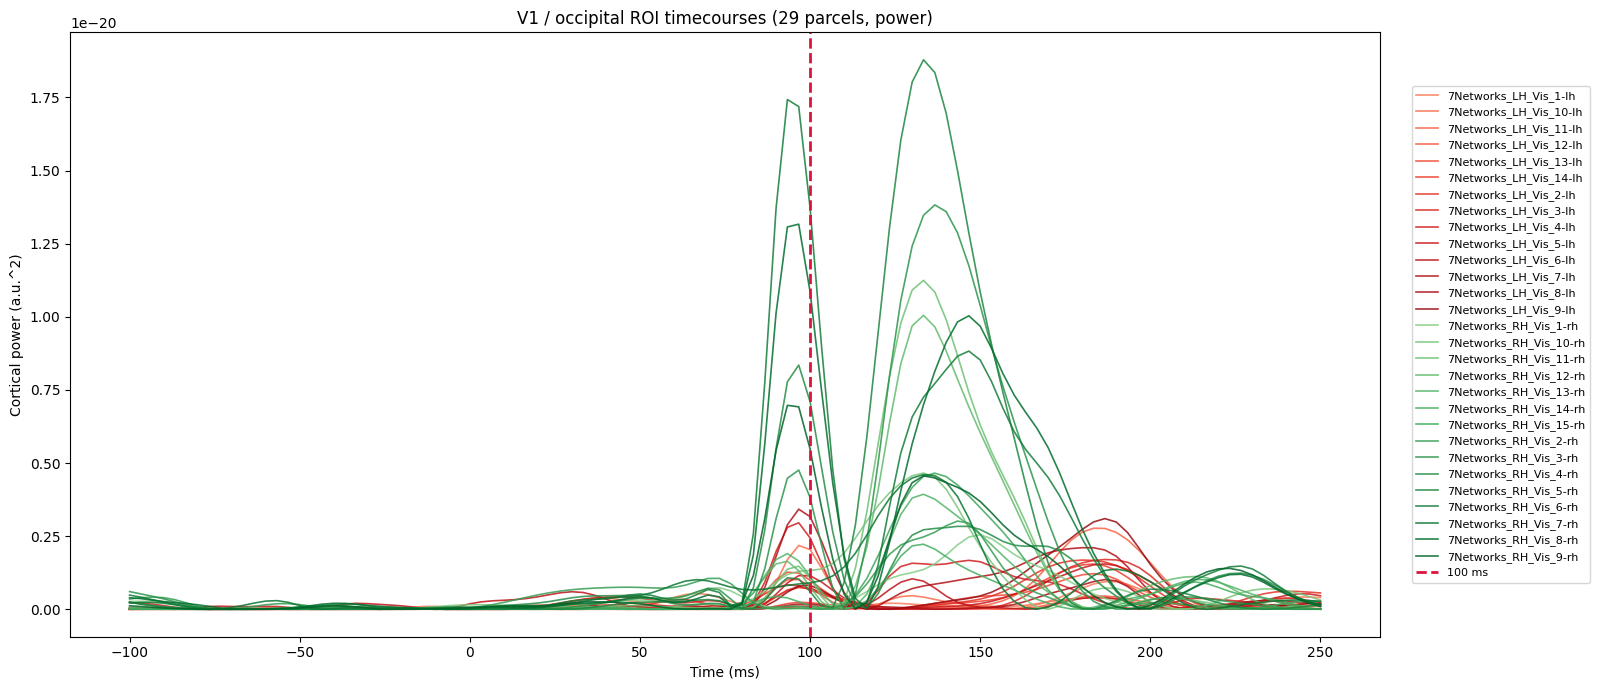

Plotted 29 V1/occipital ROI timecourses on one axes.
LH parcels: 14, RH parcels: 15, unlabeled: 0
Metric mode: power
V1/occipital proxy ROIs used:
  - 7Networks_LH_Vis_1-lh
  - 7Networks_LH_Vis_10-lh
  - 7Networks_LH_Vis_11-lh
  - 7Networks_LH_Vis_12-lh
  - 7Networks_LH_Vis_13-lh
  - 7Networks_LH_Vis_14-lh
  - 7Networks_LH_Vis_2-lh
  - 7Networks_LH_Vis_3-lh
  - 7Networks_LH_Vis_4-lh
  - 7Networks_LH_Vis_5-lh
  - 7Networks_LH_Vis_6-lh
  - 7Networks_LH_Vis_7-lh
  - 7Networks_LH_Vis_8-lh
  - 7Networks_LH_Vis_9-lh
  - 7Networks_RH_Vis_1-rh
  - 7Networks_RH_Vis_10-rh
  - 7Networks_RH_Vis_11-rh
  - 7Networks_RH_Vis_12-rh
  - 7Networks_RH_Vis_13-rh
  - 7Networks_RH_Vis_14-rh
  - 7Networks_RH_Vis_15-rh
  - 7Networks_RH_Vis_2-rh
  - 7Networks_RH_Vis_3-rh
  - 7Networks_RH_Vis_4-rh
  - 7Networks_RH_Vis_5-rh
  - 7Networks_RH_Vis_6-rh
  - 7Networks_RH_Vis_7-rh
  - 7Networks_RH_Vis_8-rh
  - 7Networks_RH_Vis_9-rh


In [11]:
%matplotlib inline

v1_patterns = ('vis', 'pericalcarine', 'calcarine', 'occipital', 'v1')
v1_idxs = [
    idx for idx, roi_name in enumerate(roi_names)
    if any(pattern in roi_name.lower() for pattern in v1_patterns)
]
if not v1_idxs:
    raise RuntimeError('No occipital/V1 proxy ROI names found in this atlas export.')

lh_idxs = [idx for idx in v1_idxs if '-lh' in roi_names[idx].lower() or '_lh_' in roi_names[idx].lower()]
rh_idxs = [idx for idx in v1_idxs if '-rh' in roi_names[idx].lower() or '_rh_' in roi_names[idx].lower()]
other_idxs = [idx for idx in v1_idxs if idx not in lh_idxs and idx not in rh_idxs]

lh_colors = plt.cm.Reds(np.linspace(0.45, 0.9, max(len(lh_idxs), 1)))
rh_colors = plt.cm.Greens(np.linspace(0.45, 0.9, max(len(rh_idxs), 1)))
other_colors = plt.cm.Greys(np.linspace(0.45, 0.75, max(len(other_idxs), 1)))

plt.figure(figsize=(14, 7))
for color, roi_idx in zip(lh_colors, lh_idxs):
    plt.plot(
        roi_times_s * 1e3,
        roi_metric_data[roi_idx],
        linewidth=1.2,
        alpha=0.85,
        color=color,
        label=roi_names[roi_idx],
    )
for color, roi_idx in zip(rh_colors, rh_idxs):
    plt.plot(
        roi_times_s * 1e3,
        roi_metric_data[roi_idx],
        linewidth=1.2,
        alpha=0.85,
        color=color,
        label=roi_names[roi_idx],
    )
for color, roi_idx in zip(other_colors, other_idxs):
    plt.plot(
        roi_times_s * 1e3,
        roi_metric_data[roi_idx],
        linewidth=1.2,
        alpha=0.85,
        color=color,
        label=roi_names[roi_idx],
    )

plt.axvline(target_time_ms, color='crimson', linestyle='--', linewidth=2, label=f'{target_time_ms:.0f} ms')
plt.xlabel('Time (ms)')
plt.ylabel(metric_label)
plt.title(f'V1 / occipital ROI timecourses ({len(v1_idxs)} parcels, {metric_mode})')
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()

print(f'Plotted {len(v1_idxs)} V1/occipital ROI timecourses on one axes.')
print(f'LH parcels: {len(lh_idxs)}, RH parcels: {len(rh_idxs)}, unlabeled: {len(other_idxs)}')
print(f'Metric mode: {metric_mode}')
print('V1/occipital proxy ROIs used:')
for roi_idx in v1_idxs:
    print(f'  - {roi_names[roi_idx]}')